# Data Collection
## Pulling and caching market data with yfinance

Raw OHLCV data is the starting point of every financial TDA pipeline. We use `yfinance` to pull historical price data and cache it locally to avoid redundant API calls.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Pull S&P 500 data
ticker = yf.Ticker("^GSPC")
df = ticker.history(start="2000-01-01", end="2024-01-01")

print(df.shape)
print(df.head())

(6037, 7)
                                  Open         High          Low        Close  \
Date                                                                            
2000-01-03 00:00:00-05:00  1469.250000  1478.000000  1438.359985  1455.219971   
2000-01-04 00:00:00-05:00  1455.219971  1455.219971  1397.430054  1399.420044   
2000-01-05 00:00:00-05:00  1399.420044  1413.270020  1377.680054  1402.109985   
2000-01-06 00:00:00-05:00  1402.109985  1411.900024  1392.099976  1403.449951   
2000-01-07 00:00:00-05:00  1403.449951  1441.469971  1400.729980  1441.469971   

                               Volume  Dividends  Stock Splits  
Date                                                            
2000-01-03 00:00:00-05:00   931800000        0.0           0.0  
2000-01-04 00:00:00-05:00  1009000000        0.0           0.0  
2000-01-05 00:00:00-05:00  1085500000        0.0           0.0  
2000-01-06 00:00:00-05:00  1092300000        0.0           0.0  
2000-01-07 00:00:00-05:00  12252

## Data Overview

We pull daily OHLCV (Open, High, Low, Close, Volume) data for the S&P 500 index (`^GSPC`) from January 2000 to January 2024 — covering three major market crises:

- **2000-2002** — Dot-com crash
- **2008-2009** — Global Financial Crisis
- **2020** — COVID crash

6037 trading days of data. We will use the **Close price** as our primary time series.

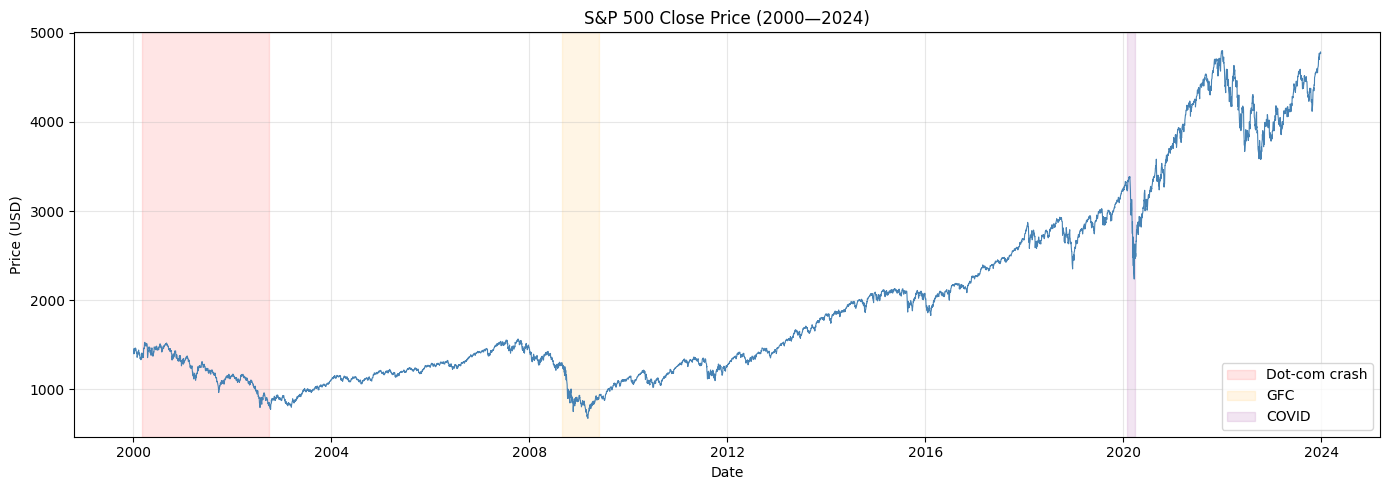

In [4]:
# Plot S&P 500 Close price
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=0.8)
plt.title('S&P 500 Close Price (2000—2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)

# Mark the three crises
plt.axvspan('2000-03-01', '2002-10-01', alpha=0.1, color='red', label='Dot-com crash')
plt.axvspan('2008-09-01', '2009-06-01', alpha=0.1, color='orange', label='GFC')
plt.axvspan('2020-02-01', '2020-04-01', alpha=0.1, color='purple', label='COVID')

plt.legend()
plt.tight_layout()
plt.show()

## Price Series

The three crisis periods are clearly visible as sharp drawdowns in the price series. Our TDA pipeline will operate on **returns**, not prices — so the next step is preprocessing.

Note: crisis windows are approximate and used for visual reference only.

In [5]:
# Cache data locally to avoid redundant API calls
import os

os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/sp500_2000_2024.csv')
print("Data cached to ../data/raw/sp500_2000_2024.csv")

Data cached to ../data/raw/sp500_2000_2024.csv


## Reusable Data Collection

The data collection logic is encapsulated in `src/data.py` — making it reusable across all future repos. Any ticker, any date range, with automatic local caching.

In [1]:
import sys
sys.path.insert(0, '/home/gabo-linux/TDA-Gabo/tda-financial-data-pipeline')

from src.data import fetch_ticker
df_test = fetch_ticker('^GSPC', '2000-01-01', '2024-01-01')
print(df_test.shape)

Loading from cache: ../data/raw/GSPC_2000-01-01_2024-01-01.csv
(6037, 7)


## Conclusions

The data collection pipeline is complete:

- `fetch_ticker()` pulls any ticker from Yahoo Finance for any date range
- Data is cached locally on first call — subsequent calls load instantly from disk
- 6037 trading days of S&P 500 data ready for preprocessing

Next: compute returns, handle missing data, and normalize the series.